# Credit risk: modelling

Picks up from `credit_risk_clean.csv`, which still has its missing values in it because
imputation is a fitted step and belongs on this side of the split.



## 1. Load and feature groups

`loan_grade` and `loan_int_rate` come from the lender's own model, so I leave them out. Everything
below uses applicant data only, and section 7 adds the two columns back to see how much they'd
help.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

RANDOM_STATE = 67
TARGET = "loan_status"

df = pd.read_csv("credit_risk_clean.csv")

NUMERIC_ALL = ["person_age", "person_income", "person_emp_length", "loan_amnt",
               "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
CATEGORICAL_ALL = ["person_home_ownership", "loan_intent", "loan_grade",
                   "cb_person_default_on_file"]
LENDER = ["loan_grade", "loan_int_rate"]

# The main models use applicant data only. The lender columns come back in section 7.
NUMERIC = [c for c in NUMERIC_ALL if c not in LENDER]
CATEGORICAL = [c for c in CATEGORICAL_ALL if c not in LENDER]

X = df[NUMERIC_ALL + CATEGORICAL_ALL]
y = df[TARGET]

print(f"{len(df):,} rows, {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical applicant features")
print(f"default rate {y.mean():.4f}")
print(f"lender columns, only used in section 7: {LENDER}")

32,416 rows, 6 numeric + 3 categorical applicant features
default rate 0.2187
lender columns, only used in section 7: ['loan_grade', 'loan_int_rate']


## 2. Split

The data is stratified at 0.2187 to make sure that an unlucky shuffle does not make the training data sparse with positives. There is no date/time data, so no need to consider any chronological split.

Everything after this point that learns anything from data learns it from `X_train` only.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train {len(X_train):,} rows, default rate {y_train.mean():.4f}")
print(f"test  {len(X_test):,} rows, default rate {y_test.mean():.4f}")

assert len(X_train) == 25932 and len(X_test) == 6484
assert round(y_train.mean(), 3) == round(y_test.mean(), 3) == 0.219

train 25,932 rows, default rate 0.2187
test  6,484 rows, default rate 0.2187


## 3. Two preprocessors

Logistic regression and HGB approach NaN values in different ways. 

Logistic regression can't take a NaN and needs features on similar scales, so it gets median
imputation, an indicator column for rows that were originally blank, and a standard scaler.
`person_income` is logged first because of the long right tail. The one-hot encoder ignores
unknown categories instead of erroring, since a rare category could be missing from a CV fold.

HistGradientBoosting has no problem processing the NaN values. It decides at each split which
direction missing values should go, which is how the 31.5% default rate among blank employment
histories gets leveraged instead of being averaged away. Categoricals go through an ordinal
encoder, and I pass their column positions to the model so it treats them as categories, not
ordered numbers.

Both are functions of the feature list so the with/without runs use the same code.

In [3]:
def lr_pipeline(num_cols, cat_cols, class_weight=None):
    skewed = [c for c in num_cols if c == "person_income"]
    plain = [c for c in num_cols if c != "person_income"]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), plain),
        ("skew", Pipeline([
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), skewed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    return Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(max_iter=2000, class_weight=class_weight,
                                     random_state=RANDOM_STATE)),
    ])


def hgb_pipeline(num_cols, cat_cols, class_weight=None, **params):
    # Categoricals first so their positions after the transform are 0..len(cat_cols)-1.
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan,
                               encoded_missing_value=np.nan), cat_cols),
        ("num", "passthrough", num_cols),
    ])
    return Pipeline([
        ("pre", pre),
        ("model", HistGradientBoostingClassifier(
            categorical_features=list(range(len(cat_cols))),
            class_weight=class_weight, random_state=RANDOM_STATE, **params)),
    ])


def evaluate(pipe, name, num_cols, cat_cols):
    # Fit on train, score once on test.
    cols = num_cols + cat_cols
    pipe.fit(X_train[cols], y_train)
    proba = pipe.predict_proba(X_test[cols])[:, 1]
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "_proba": proba,
        "_fitted": pipe,
    }

print("preprocessing built; nothing fitted yet")

preprocessing built; nothing fitted yet


## 4. Logistic regression baseline

This is the number everything else gets measured against. Nothing is tuned here, and it only uses
applicant data, same as every model after it.

In [4]:
results = []

baseline = evaluate(lr_pipeline(NUMERIC, CATEGORICAL), "Logistic regression (baseline)",
                    NUMERIC, CATEGORICAL)
results.append(baseline)

print(f"AUC-ROC  {baseline['roc_auc']:.4f}")
print(f"PR-AUC   {baseline['pr_auc']:.4f}   (floor is the base rate, {y_test.mean():.4f})")

AUC-ROC  0.8198
PR-AUC   0.6486   (floor is the base rate, 0.2187)


## 5. Class imbalance

21.9% of loans default. The usual fix is `class_weight="balanced"`, which weights each class by
inverse frequency so the 5,671 training defaults count as much in total as the 20,261
repayments. I'd take that over SMOTE, since it doesn't create synthetic rows and gets
reapplied inside every CV fold automatically, while SMOTE done before the split or on a
validation fold leaks.

I tested it against the unweighted baseline below and ended up not using it.

In [5]:
balanced_lr = evaluate(lr_pipeline(NUMERIC, CATEGORICAL, class_weight="balanced"),
                       "Logistic regression (balanced)", NUMERIC, CATEGORICAL)

print(f"{'':34} {'AUC-ROC':>8} {'PR-AUC':>8}")
for r in (baseline, balanced_lr):
    print(f"{r['model']:34} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f}")

print(f"\nclass counts in train: {dict(y_train.value_counts())}")

                                    AUC-ROC   PR-AUC
Logistic regression (baseline)       0.8198   0.6486
Logistic regression (balanced)       0.8205   0.6376

class counts in train: {0: np.int64(20261), 1: np.int64(5671)}


Balancing barely moved AUC-ROC (0.8205 vs 0.8198) and lowered PR-AUC (0.6376 vs 0.6486). Both
metrics only care about how predictions are ranked, and reweighting mostly shifts the
probabilities up without changing their order much, so it has little to add.

What it does change is the probabilities themselves. A balanced model is trained as if
defaults were half the data, so its predictions run high: the balanced HGB in section 9
averages 0.36 against a real default rate of 0.22. The threshold uses the probabilities
directly, so I leave the weighting off and let the cost matrix handle the imbalance instead.

## 6. HistGradientBoosting, tuned without touching test

Hyperparameters are picked with 5-fold cross-validation on the training set. Each fold refits
the whole pipeline, encoder included, so nothing is learned from the fold being scored.

Scored on `average_precision` (PR-AUC). Tuning on accuracy would favour models that just
predict "no default" more often.

The test set is not involved in any of this, only the training set.

In [6]:
param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__max_iter": [100, 300],
}

search = GridSearchCV(
    hgb_pipeline(NUMERIC, CATEGORICAL),
    param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
search.fit(X_train[NUMERIC + CATEGORICAL], y_train)

print("best params:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nbest cross-validated PR-AUC on train: {search.best_score_:.4f}")

best params:
  learning_rate: 0.05
  max_iter: 300
  max_leaf_nodes: 31

best cross-validated PR-AUC on train: 0.8082


In [7]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}

hgb = evaluate(hgb_pipeline(NUMERIC, CATEGORICAL, **best_params),
               "HistGradientBoosting", NUMERIC, CATEGORICAL)
results.append(hgb)

print(f"{'':34} {'AUC-ROC':>8} {'PR-AUC':>8}")
for r in (baseline, hgb):
    print(f"{r['model']:34} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f}")

lift = hgb["pr_auc"] - baseline["pr_auc"]
print(f"\nPR-AUC gain over the baseline: {lift:+.4f}")

                                    AUC-ROC   PR-AUC
Logistic regression (baseline)       0.8198   0.6486
HistGradientBoosting                 0.9010   0.8166

PR-AUC gain over the baseline: +0.1680


## 7. With and without the lender's judgement

The lender assigns `loan_grade` and `loan_int_rate` after assessing the application, so a model
using them is partly predicting the lender's own model. That's why the rest of the notebook leaves
them out. Here I add them back to both models to see how much they'd add.

In [8]:
lr_with = evaluate(lr_pipeline(NUMERIC_ALL, CATEGORICAL_ALL),
                   "Logistic regression", NUMERIC_ALL, CATEGORICAL_ALL)

search_with = GridSearchCV(hgb_pipeline(NUMERIC_ALL, CATEGORICAL_ALL), param_grid,
                           scoring="average_precision", cv=5, n_jobs=-1)
search_with.fit(X_train[NUMERIC_ALL + CATEGORICAL_ALL], y_train)
best_with = {k.replace("model__", ""): v for k, v in search_with.best_params_.items()}

hgb_with = evaluate(hgb_pipeline(NUMERIC_ALL, CATEGORICAL_ALL, **best_with),
                    "HistGradientBoosting", NUMERIC_ALL, CATEGORICAL_ALL)

print(f"added back {LENDER}, {len(NUMERIC_ALL) + len(CATEGORICAL_ALL)} features")

added back ['loan_grade', 'loan_int_rate'], 11 features


In [9]:
rows = [
    ("Logistic regression", lr_with, baseline),
    ("HistGradientBoosting", hgb_with, hgb),
]

print(f"{'':22} {'with lender cols':>26}    {'without':>18}")
print(f"{'':22} {'AUC-ROC':>12} {'PR-AUC':>13}    {'AUC-ROC':>8} {'PR-AUC':>9}")
for name, w, wo in rows:
    print(f"{name:22} {w['roc_auc']:12.4f} {w['pr_auc']:13.4f}    "
          f"{wo['roc_auc']:8.4f} {wo['pr_auc']:9.4f}")

print()
for name, w, wo in rows:
    print(f"{name}: the lender columns add "
          f"{w['roc_auc'] - wo['roc_auc']:.4f} AUC-ROC and "
          f"{w['pr_auc'] - wo['pr_auc']:.4f} PR-AUC")

                                 with lender cols               without
                            AUC-ROC        PR-AUC     AUC-ROC    PR-AUC
Logistic regression          0.8776        0.7434      0.8198    0.6486
HistGradientBoosting         0.9491        0.9078      0.9010    0.8166

Logistic regression: the lender columns add 0.0578 AUC-ROC and 0.0948 PR-AUC
HistGradientBoosting: the lender columns add 0.0481 AUC-ROC and 0.0912 PR-AUC


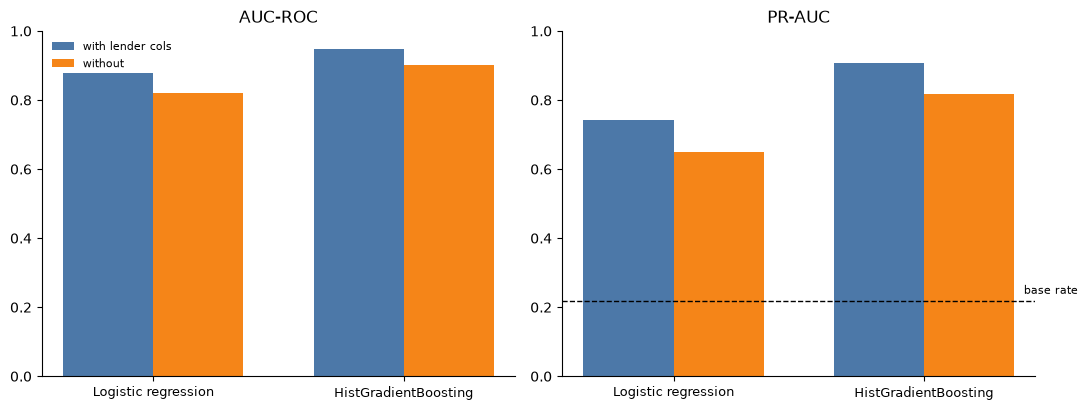

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, (key, label) in zip(axes, [("roc_auc", "AUC-ROC"), ("pr_auc", "PR-AUC")]):
    names = [n for n, _, _ in rows]
    xs = np.arange(len(names))
    ax.bar(xs - 0.18, [w[key] for _, w, _ in rows], 0.36, label="with lender cols",
           color="#4C78A8")
    ax.bar(xs + 0.18, [wo[key] for _, _, wo in rows], 0.36, label="without",
           color="#F58518")
    ax.set_xticks(xs, names, fontsize=9)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    if key == "pr_auc":
        ax.axhline(y_test.mean(), ls="--", lw=1, color="black")
        ax.text(1.4, y_test.mean() + 0.02, "base rate", fontsize=8)
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

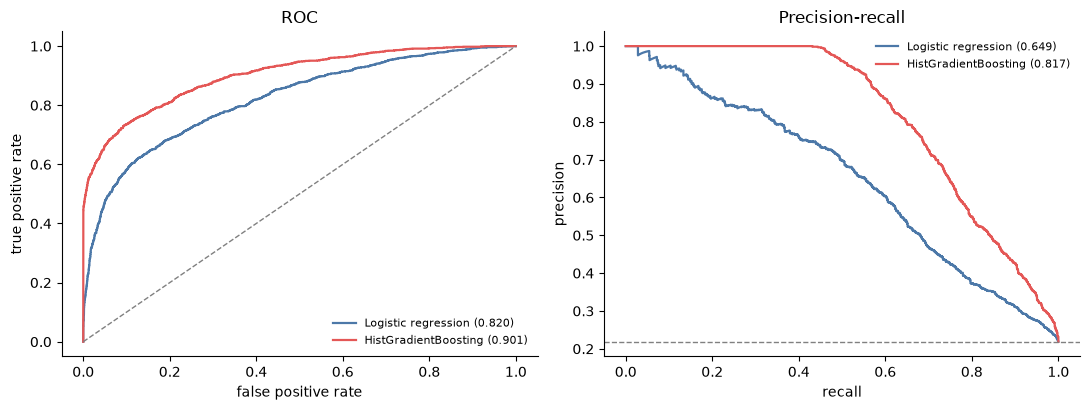

In [11]:
# ROC and PR curves for the two headline models.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for r, color in [(baseline, "#4C78A8"), (hgb, "#E45756")]:
    fpr, tpr, _ = roc_curve(y_test, r["_proba"])
    axes[0].plot(fpr, tpr, color=color, lw=1.6,
                 label=f"{r['model'].split(' (')[0]} ({r['roc_auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, r["_proba"])
    axes[1].plot(rec, prec, color=color, lw=1.6,
                 label=f"{r['model'].split(' (')[0]} ({r['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], ls="--", lw=1, color="grey")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC")
axes[1].axhline(y_test.mean(), ls="--", lw=1, color="grey")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall")
for ax in axes:
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. What drives the predictions

For logistic regression I use the coefficients. Exponentiated, each one is an odds ratio: how
much the odds of default multiply for a one standard deviation increase in a numeric feature,
or for being in a given category. Above 1 raises risk, below 1 lowers it.

HGB has no coefficients, so I use SHAP, which gives each feature a signed contribution to each
prediction. Averaging the absolute values ranks features by how much the model relies on them.

In [12]:
lr_fitted = baseline["_fitted"]
feature_names = lr_fitted.named_steps["pre"].get_feature_names_out()
coefs = lr_fitted.named_steps["model"].coef_[0]

coef_tbl = (pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(odds_ratio=lambda d: np.exp(d["coef"]),
                      abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
              .head(15)
              .drop(columns="abs_coef"))

print("Top 15 logistic regression coefficients (standardised features)")
print(coef_tbl.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

Top 15 logistic regression coefficients (standardised features)
                            feature     coef  odds_ratio
     cat__person_home_ownership_OWN  -1.5810      0.2058
   cat__cb_person_default_on_file_N  -0.9599      0.3829
                skew__person_income  -0.7448      0.4748
           cat__loan_intent_VENTURE  -0.6775      0.5079
    cat__person_home_ownership_RENT   0.5867      1.7980
           num__loan_percent_income   0.5799      1.7858
         cat__loan_intent_EDUCATION  -0.5307      0.5882
   cat__loan_intent_HOMEIMPROVEMENT   0.4207      1.5231
   cat__person_home_ownership_OTHER   0.3560      1.4276
          cat__loan_intent_PERSONAL  -0.3360      0.7146
                     num__loan_amnt   0.3136      1.3684
 cat__loan_intent_DEBTCONSOLIDATION   0.2377      1.2684
cat__person_home_ownership_MORTGAGE  -0.1916      0.8256
   cat__cb_person_default_on_file_Y   0.1300      1.1388
           cat__loan_intent_MEDICAL   0.0558      1.0574


In [13]:
import shap

hgb_fitted = hgb["_fitted"]
pre = hgb_fitted.named_steps["pre"]
model = hgb_fitted.named_steps["model"]

hgb_feature_names = CATEGORICAL + NUMERIC          # ColumnTransformer order: cat then num
sample = X_test[NUMERIC + CATEGORICAL].sample(1000, random_state=RANDOM_STATE)
X_sample = pd.DataFrame(pre.transform(sample), columns=hgb_feature_names)

try:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    method = "TreeExplainer"
except Exception as exc:                            # noqa: BLE001
    print(f"TreeExplainer unavailable ({type(exc).__name__}), falling back")
    background = shap.sample(
        pd.DataFrame(pre.transform(X_train[NUMERIC + CATEGORICAL].sample(200, random_state=RANDOM_STATE)),
                     columns=hgb_feature_names), 100, random_state=RANDOM_STATE)
    explainer = shap.Explainer(model.predict_proba, background)
    shap_values = explainer(X_sample).values[..., 1]
    method = "Explainer fallback"

print(f"{method}: shap values shape {np.asarray(shap_values).shape}")

/home/taidd/personal-projects/credit-risk-ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TreeExplainer: shap values shape (1000, 9)


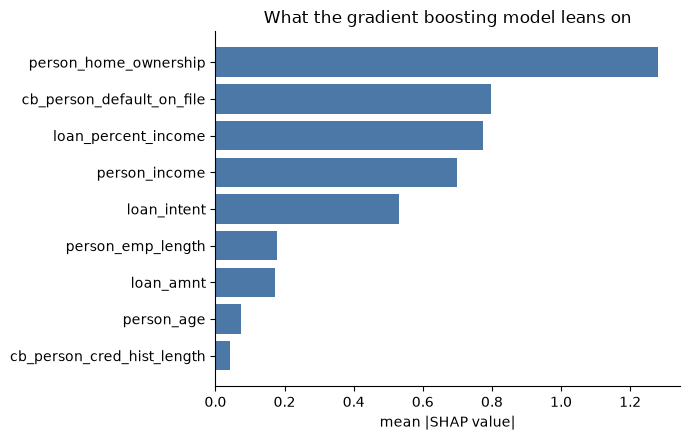

person_home_ownership        1.2801
cb_person_default_on_file    0.7969
loan_percent_income          0.7747
person_income                0.6985
loan_intent                  0.5312
person_emp_length            0.1790
loan_amnt                    0.1726
person_age                   0.0737
cb_person_cred_hist_length   0.0435


In [14]:
sv = np.asarray(shap_values)
if sv.ndim == 3:                                    # (n, features, classes)
    sv = sv[..., 1]

mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=hgb_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(mean_abs.index, mean_abs.values, color="#4C78A8")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("What the gradient boosting model leans on")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(mean_abs.sort_values(ascending=False).to_string(float_format=lambda v: f"{v:.4f}"))

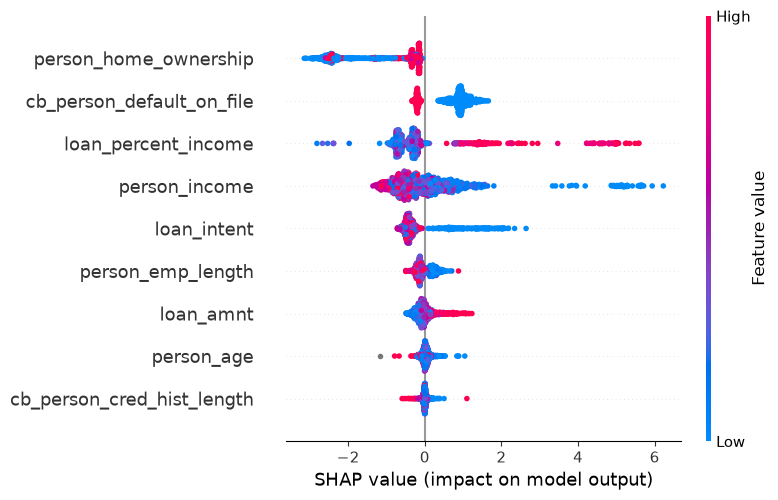

In [15]:
shap.summary_plot(sv, X_sample, feature_names=hgb_feature_names, show=False, max_display=11)
plt.tight_layout()
plt.show()

## 9. Probabilities for the threshold

Every model above outputs a probability of default, and the usual 0.5 cutoff treats a missed
default and a wrongly declined customer as equally bad. They aren't, so the cutoff has to come
from what each mistake actually costs.

The cell below saves the test labels and the HGB probabilities to `preds.npz` so the threshold
work doesn't need a refit. I also refit the same HGB with `class_weight="balanced"` to compare.

The unweighted model averages 0.2178 against a real default rate of 0.2187. The balanced one
averages 0.3574 and scores a little lower on both metrics. The threshold uses the probabilities
directly, so I'm going with the unweighted ones (`y_proba`).

In [16]:
# Pick the model on cross-validated PR-AUC from the training set, not on test scores.
lr_cv = cross_val_score(lr_pipeline(NUMERIC, CATEGORICAL), X_train[NUMERIC + CATEGORICAL], y_train,
                        scoring="average_precision", cv=5).mean()
cv_scores = {baseline["model"]: lr_cv, hgb["model"]: search.best_score_}
best = next(r for r in results if r["model"] == max(cv_scores, key=cv_scores.get))
print("cross-validated PR-AUC on train: " + ", ".join(f"{k} {v:.4f}" for k, v in cv_scores.items()) + "\n")

# Same model refit with class_weight="balanced", only to show how weighting inflates
# the probabilities. The unweighted model is the one to threshold on.
balanced = evaluate(hgb_pipeline(NUMERIC, CATEGORICAL, class_weight="balanced", **best_params),
                    "HistGradientBoosting (balanced)", NUMERIC, CATEGORICAL)

np.savez("preds.npz",
         y_test=y_test.to_numpy(),
         y_proba=best["_proba"],
         y_proba_balanced=balanced["_proba"],
         model_name=np.array(best["model"]))

print(f"saved preds.npz  ({best['model']}, {len(y_test):,} test rows)\n")
print(f"{'':26} {'AUC-ROC':>8} {'PR-AUC':>8} {'mean p':>8}")
for label, r in [("no class weight", best), ("class_weight=balanced", balanced)]:
    print(f"{label:26} {r['roc_auc']:8.4f} {r['pr_auc']:8.4f} {r['_proba'].mean():8.4f}")
print(f"{'actual default rate':26} {'':8} {'':8} {y_test.mean():8.4f}")

print("\nload with:  d = np.load('preds.npz')")
print("  d['y_test']            true labels")
print("  d['y_proba']           unweighted, for threshold")
print("  d['y_proba_balanced']  balanced, for comparison only")

cross-validated PR-AUC on train: Logistic regression (baseline) 0.6391, HistGradientBoosting 0.8082



saved preds.npz  (HistGradientBoosting, 6,484 test rows)

                            AUC-ROC   PR-AUC   mean p
no class weight              0.9010   0.8166   0.2178
class_weight=balanced        0.8978   0.8101   0.3574
actual default rate                            0.2187

load with:  d = np.load('preds.npz')
  d['y_test']            true labels
  d['y_proba']           unweighted, for threshold
  d['y_proba_balanced']  balanced, for comparison only


## 10. Cost-based threshold

C_FN: cost of false negative (approving loan that defaults)
- loan_amt * LGD

C_FP: cost of false positive (declining good customer)
- loan_amt * margin

The threshold should minimize the loss:
t* = C_FP / (C_FP + C_FN)
t* = margin / (margin + LGD)

In [17]:
margins = [0.02, 0.03, 0.05, 0.07, 0.10]
LGDs = [0.20, 0.30, 0.45, 0.60, 0.75]

threshold_matrix = pd.DataFrame(
    [
        [margin / (margin + lgd) for lgd in LGDs]
        for margin in margins
    ],
    index=[f"{m:.0%}" for m in margins],
    columns=[f"{l:.0%}" for l in LGDs],
)

threshold_matrix.index.name = "Margin"
threshold_matrix.columns.name = "LGD"

threshold_matrix.style.format("{:.1%}")

LGD,20%,30%,45%,60%,75%
Margin,,,,,
2%,9.1%,6.2%,4.3%,3.2%,2.6%
3%,13.0%,9.1%,6.2%,4.8%,3.8%
5%,20.0%,14.3%,10.0%,7.7%,6.2%
7%,25.9%,18.9%,13.5%,10.4%,8.5%
10%,33.3%,25.0%,18.2%,14.3%,11.8%


I'll be using the 0.45 LGD with 5% margin as a baseline assumption to apply to the test probabilities.

Why these two numbers:

LGD 0.45. The data has no recovery information, so this is an assumption. These look like
unsecured personal loans (nothing over $35,000, no mortgage or auto purpose), so there's no
collateral, and recovery comes from collections or selling the debt. 0.45 is the Basel II
foundation IRB value for senior unsecured claims on companies. It sits above the 30% floor
Basel III puts on modelled LGD for unsecured retail loans, but studies of Lending Club
charged-off loans report small recoveries, so the real figure for loans like these could be
higher. The grid above goes up to 75% to cover that, and the 20% column is below the floor, so
it's a best case.

Margin 5%. The average interest rate is 11.0%. Taking off roughly 6 to 7% for funding and
servicing leaves about 4 to 5% a year. The loans amortize, so the average balance is about half
the amount borrowed, and the data has no loan term, so I assume about 2 years. That comes out to
roughly 5% of the loan amount. A longer term would push it higher, which is why the grid goes up
to 10%.

Both costs are applied to the original loan amount because there's no repayment history, which
overstates the loss on loans that default late.

In [18]:
def evaluate_threshold(threshold, y_true, y_proba, loan_amt, margin, LGD):
    y_pred = (y_proba >= threshold).astype(int)

    # Actual default + approved
    fn = (y_true == 1) & (y_pred == 0)

    # Actual non-default + declined
    fp = (y_true == 0) & (y_pred == 1)

    fn_cost = np.sum(loan_amt[fn] * LGD)
    fp_cost = np.sum(loan_amt[fp] * margin)

    return {
        "threshold": threshold,
        "defaults_approved": fn.sum(),
        "good_loans_declined": fp.sum(),
        "FN_cost": fn_cost,
        "FP_cost": fp_cost,
        "total_cost": fn_cost + fp_cost
    }

In [19]:
d = np.load("preds.npz")

y_true = d["y_test"]
y_proba = d["y_proba"]
loan_amt = X_test["loan_amnt"].to_numpy()

margin = 0.05
LGD = 0.45

threshold = margin / (margin + LGD)


result = evaluate_threshold(
    threshold,
    y_true,
    y_proba,
    loan_amt,
    margin,
    LGD
)

result

{'threshold': 0.1,
 'defaults_approved': np.int64(133),
 'good_loans_declined': np.int64(1857),
 'FN_cost': np.float64(578621.25),
 'FP_cost': np.float64(829590.0),
 'total_cost': np.float64(1408211.25)}

### Compared to 0.5 and approving everyone

Same costs (LGD 0.45, 5% margin) for all three, so the only thing changing is the cutoff.

In [20]:
policies = [
    (f"cost-based ({threshold:.2f})", threshold),
    ("default 0.5", 0.5),
    ("approve everyone", np.inf),   # nothing clears an infinite cutoff, so every loan is approved
]

rows = []
for label, t in policies:
    r = evaluate_threshold(t, y_true, y_proba, loan_amt, margin, LGD)
    r["policy"] = label
    r["decline_rate"] = (y_proba >= t).mean()
    rows.append(r)

comparison = pd.DataFrame(rows).set_index("policy")[
    ["defaults_approved", "good_loans_declined", "decline_rate", "FN_cost", "FP_cost", "total_cost"]
]
print(comparison.to_string(formatters={
    "decline_rate": "{:.1%}".format,
    "FN_cost": "${:,.0f}".format,
    "FP_cost": "${:,.0f}".format,
    "total_cost": "${:,.0f}".format,
}))

cost = comparison["total_cost"]
best_label = policies[0][0]
print(f"\nsaving vs 0.5:              ${cost['default 0.5'] - cost[best_label]:,.0f}")
print(f"saving vs approve everyone: ${cost['approve everyone'] - cost[best_label]:,.0f}")
print(f"\nactual default rate in test: {y_true.mean():.1%}")

                   defaults_approved  good_loans_declined decline_rate    FN_cost  FP_cost total_cost
policy                                                                                               
cost-based (0.10)                133                 1857        48.5%   $578,621 $829,590 $1,408,211
default 0.5                      627                   76        13.4% $2,570,310  $39,558 $2,609,868
approve everyone                1418                    0         0.0% $6,850,305       $0 $6,850,305

saving vs 0.5:              $1,201,656
saving vs approve everyone: $5,442,094

actual default rate in test: 21.9%


### How much the assumptions matter

The LGD and margin are guesses, so this reruns the cost-based cutoff for every combination in the
threshold table above, and compares each one to using 0.5 under the same costs.

In [21]:
rows = []
for m in margins:
    for lgd in LGDs:
        t = m / (m + lgd)
        at_t = evaluate_threshold(t, y_true, y_proba, loan_amt, m, lgd)
        at_half = evaluate_threshold(0.5, y_true, y_proba, loan_amt, m, lgd)
        rows.append({
            "margin": f"{m:.0%}", "LGD": f"{lgd:.0%}",
            "decline_rate": (y_proba >= t).mean(),
            "total_cost": at_t["total_cost"],
            "saving_vs_0.5": at_half["total_cost"] - at_t["total_cost"],
        })
sens = pd.DataFrame(rows)

def grid(col):
    return sens.pivot(index="margin", columns="LGD", values=col).loc[
        [f"{m:.0%}" for m in margins], [f"{l:.0%}" for l in LGDs]]

print("share of applicants declined")
print(grid("decline_rate").to_string(float_format="{:.1%}".format))
print("\ntotal cost at the cost-based cutoff")
print(grid("total_cost").to_string(float_format="${:,.0f}".format))
print("\nsaving vs a 0.5 cutoff under the same costs")
print(grid("saving_vs_0.5").to_string(float_format="${:,.0f}".format))

share of applicants declined
LGD      20%   30%   45%   60%   75%
margin                              
2%     51.3% 63.8% 75.2% 81.9% 85.9%
3%     40.1% 51.3% 63.8% 72.2% 78.2%
5%     28.7% 37.3% 48.5% 57.2% 63.8%
7%     23.4% 30.1% 39.0% 47.0% 53.4%
10%    18.9% 24.2% 30.8% 37.3% 43.3%

total cost at the cost-based cutoff
LGD           20%        30%        45%        60%        75%
margin                                                       
2%       $586,012   $702,266   $749,724   $780,230   $820,065
3%       $719,070   $879,019 $1,053,399 $1,111,761 $1,143,770
5%       $938,881 $1,148,881 $1,408,211 $1,597,362 $1,755,665
7%       $993,083 $1,368,303 $1,655,476 $1,894,234 $2,117,588
10%    $1,089,722 $1,482,478 $2,011,260 $2,297,762 $2,567,276

saving vs a 0.5 cutoff under the same costs
LGD         20%        30%        45%        60%        75%
margin                                                     
2%     $572,170 $1,027,097 $1,836,409 $2,662,672 $3,479,608
3%     $447,025 

## 11. Summary

Using applicant data only, HGB beats the logistic regression baseline on both metrics (0.9010 vs
0.8198 AUC-ROC, 0.8166 vs 0.6486 PR-AUC). Adding the lender's grade and interest rate would push
HGB to 0.9491 and 0.9078, but I leave them out so the model isn't partly predicting the lender's
own assessment. Tuning and model choice both used cross-validation on the training set, and the
test set was only used to score.

At LGD 0.45 and a 5% margin, the cost-based cutoff of 0.10 costs $1,201,656 less than a 0.5 cutoff
on the test set, but declines 48.5% of applicants. It beats 0.5 under every LGD and margin
combination I tried, although how many people it declines depends a lot on the margin.

Limitations for the README: LGD and margin are assumed rather than estimated, the 740 rows with
implausible employment lengths are still in, and there's no time column, so nothing here shows
how the model would do on future applicants.